In [1]:
from google.colab import files
uploaded = files.upload()

Saving negative_reviews_translated.csv to negative_reviews_translated.csv
Saving neutral_comments.csv to neutral_comments.csv
Saving positive_reviews_part1_translated.csv to positive_reviews_part1_translated.csv
Saving positive_reviews_part2_translated.csv to positive_reviews_part2_translated.csv


In [2]:
import pandas as pd

df1 = pd.read_csv('positive_reviews_part1_translated.csv')
df2 = pd.read_csv('positive_reviews_part2_translated.csv')
df3 = pd.read_csv('neutral_comments.csv')
df4 = pd.read_csv('negative_reviews_translated.csv')

In [3]:
df_all = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [4]:
df_all.head()

,review_id,app_id,rating,comment,date,sentiment,comment_en
0,672b9c70-abb1-440e-b31a-7c63d8b59297,8,5,lúc được giới thiệu về ap tôi nghĩ nó là ap ch...,2026-02-10 13:17:55,Positive,"When I was introduced to the app, I thought it..."
1,1037eda7-e173-48a3-a7dd-e2951cf1fb46,8,5,các bài học đầu tiên dễ hiểu dần tăng cấp độ c...,2026-01-17 15:19:45,Positive,The first lessons are easy to understand and g...
2,c47c22ea-61b9-47cc-b8ca-e7e8a8471bb6,8,5,tui thấy app đỉnh thiệt.à mà nhà phát triển ơi...,2025-12-04 05:55:53,Positive,I think the app is really great. Hey developer...
3,d43f5ff7-1014-4963-89f1-9febf2a96157,8,5,app này rất hay nó đã giúp tôi học các tiếng m...,2025-11-18 04:05:30,Positive,"This app is very good, it has helped me learn ..."
4,ddd2edf4-573f-47a0-9d45-8eb3eec016ad,8,4,"ở đây không thể tải ảnh lên, tôi đã học tiếng ...",2025-10-23 05:58:31,Positive,"Can't upload photos here, I learned English an..."


In [5]:
df_all = df_all.drop(columns=['sentiment'])
df_all.head()

,review_id,app_id,rating,comment,date,comment_en
0,672b9c70-abb1-440e-b31a-7c63d8b59297,8,5,lúc được giới thiệu về ap tôi nghĩ nó là ap ch...,2026-02-10 13:17:55,"When I was introduced to the app, I thought it..."
1,1037eda7-e173-48a3-a7dd-e2951cf1fb46,8,5,các bài học đầu tiên dễ hiểu dần tăng cấp độ c...,2026-01-17 15:19:45,The first lessons are easy to understand and g...
2,c47c22ea-61b9-47cc-b8ca-e7e8a8471bb6,8,5,tui thấy app đỉnh thiệt.à mà nhà phát triển ơi...,2025-12-04 05:55:53,I think the app is really great. Hey developer...
3,d43f5ff7-1014-4963-89f1-9febf2a96157,8,5,app này rất hay nó đã giúp tôi học các tiếng m...,2025-11-18 04:05:30,"This app is very good, it has helped me learn ..."
4,ddd2edf4-573f-47a0-9d45-8eb3eec016ad,8,4,"ở đây không thể tải ảnh lên, tôi đã học tiếng ...",2025-10-23 05:58:31,"Can't upload photos here, I learned English an..."


In [6]:
# 1. Overview
df_all.info()          # data types
df_all.describe()      # stats
df_all.isnull().sum()  # missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5048 entries, 0 to 5047
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   review_id   5048 non-null   object
 1   app_id      5048 non-null   int64 
 2   rating      5048 non-null   int64 
 3   comment     5048 non-null   object
 4   date        5048 non-null   object
 5   comment_en  5030 non-null   object
dtypes: int64(2), object(4)
memory usage: 236.8+ KB


,0
review_id,0
app_id,0
rating,0
comment,0
date,0
comment_en,18


In [7]:
df_all = df_all.dropna(subset=['comment_en'])

In [8]:
df_all['date'] = pd.to_datetime(df_all['date']) # convert date

In [9]:
df_all = df_all.sort_values(by='app_id', ascending=True)

In [10]:
df_all.to_csv("df_m.csv", index=False, encoding="utf-8-sig")

In [11]:
# Import thư viện xử lý dữ liệu
import pandas as pd
import numpy as np

# Import thư viện trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Thống kê cơ bản cho các cột số (ví dụ: rating)
df_all.describe()

,app_id,rating,date
count,5030.000000,5030.000000,5030
mean,4.796421,3.638569,2022-11-03 20:30:31.208946176
min,1.000000,1.000000,2013-10-26 05:57:51
25%,2.000000,2.000000,2021-01-06 11:53:07.750000128
50%,5.000000,4.000000,2022-06-15 23:06:21
75%,8.000000,5.000000,2025-04-10 11:07:12
max,10.000000,5.000000,2026-03-09 13:11:35
std,2.945165,1.610447,NaN


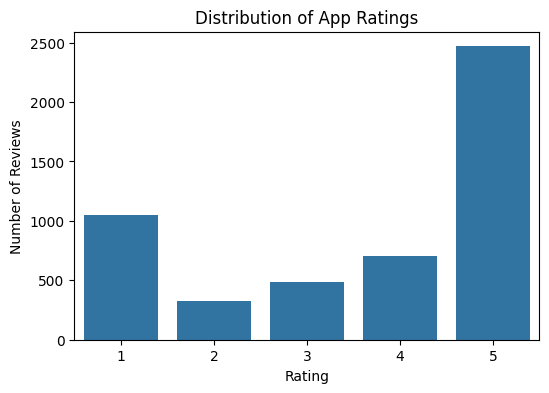

In [14]:
# Vẽ biểu đồ số lượng review theo rating

plt.figure(figsize=(6,4))

sns.countplot(x='rating', data=df_all)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

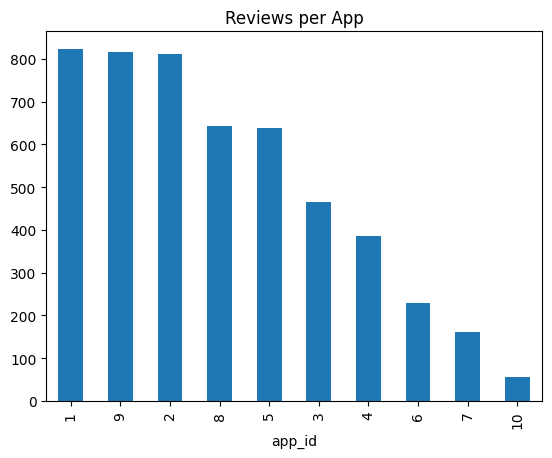

In [15]:
# Reviews per app
df_all['app_id'].value_counts().plot(kind='bar')
plt.title("Reviews per App")
plt.show()

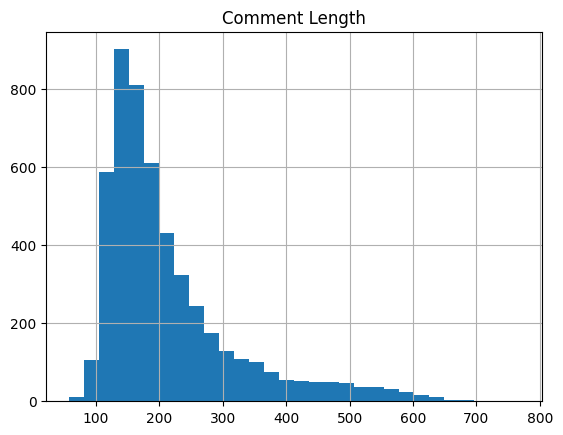

In [22]:
# Comment length
df_all['comment_length'] = df_all['comment_en'].apply(len)
df_all['comment_length'].hist(bins=30)
plt.title("Comment Length")
plt.show()

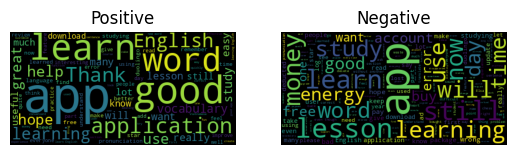

In [25]:
# 11. WordCloud by rating
pos = " ".join(df_all[df_all['rating'] >= 4]['comment_en'])
neg = " ".join(df_all[df_all['rating'] <= 2]['comment_en'])

fig, ax = plt.subplots(1,2)

ax[0].imshow(WordCloud().generate(pos))
ax[0].set_title("Positive")
ax[0].axis('off')

ax[1].imshow(WordCloud().generate(neg))
ax[1].set_title("Negative")
ax[1].axis('off')

plt.show()


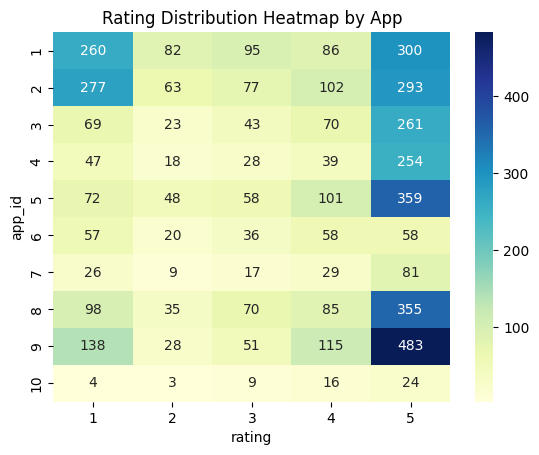

In [26]:
# Rating heatmap by app
pivot = df_all.pivot_table(index='app_id', columns='rating', aggfunc='size', fill_value=0)

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Rating Distribution Heatmap by App")  # show rating patterns
plt.show()